# Análisis de Imágenes Mal Clasificadas y Predicciones Top-K

Este notebook tiene como objetivo:

1. Mostrar imágenes mal clasificadas para analizar los errores del modelo.
2. Visualizar las `top-k` predicciones para una imagen específica.

In [1]:
# Importar las bibliotecas necesarias
import os
import sys
import matplotlib.pyplot as plt
from PIL import Image
import json
import pandas as pd
from pathlib import Path
import torch
from torchvision import transforms

# Añadir el directorio raíz del proyecto al sys.path
ROOT = Path("..").resolve()
sys.path.append(str(ROOT))

from utils.model import build_model
from utils.database import load_yaml_config

# Configuración inicial
EXPERIMENTS_PATH = os.path.join(ROOT, "experiments")
RESULTS_FILE = "results/metrics.json"
TOP_K = 5

## Mostrar Imágenes Mal Clasificadas

En esta sección, identificaremos y visualizaremos las imágenes que el modelo clasificó incorrectamente.

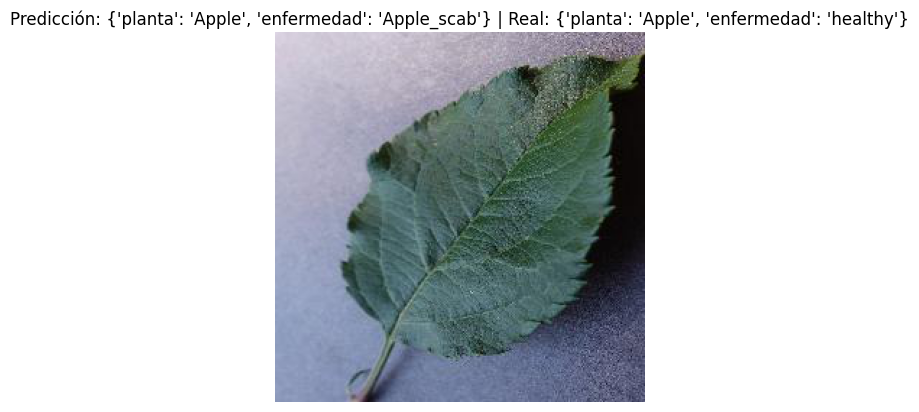

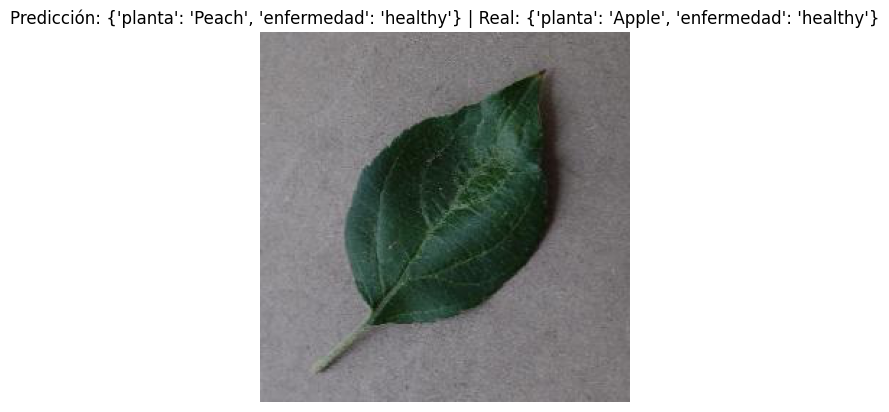

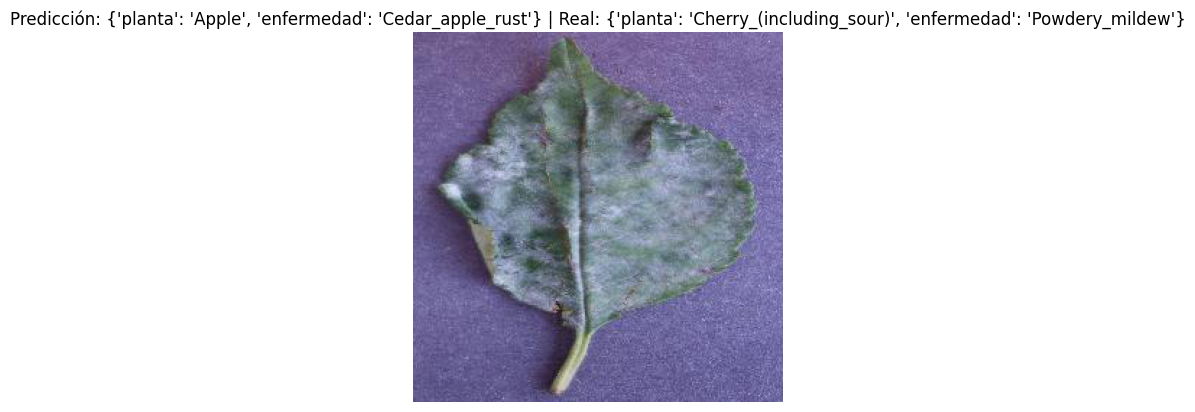

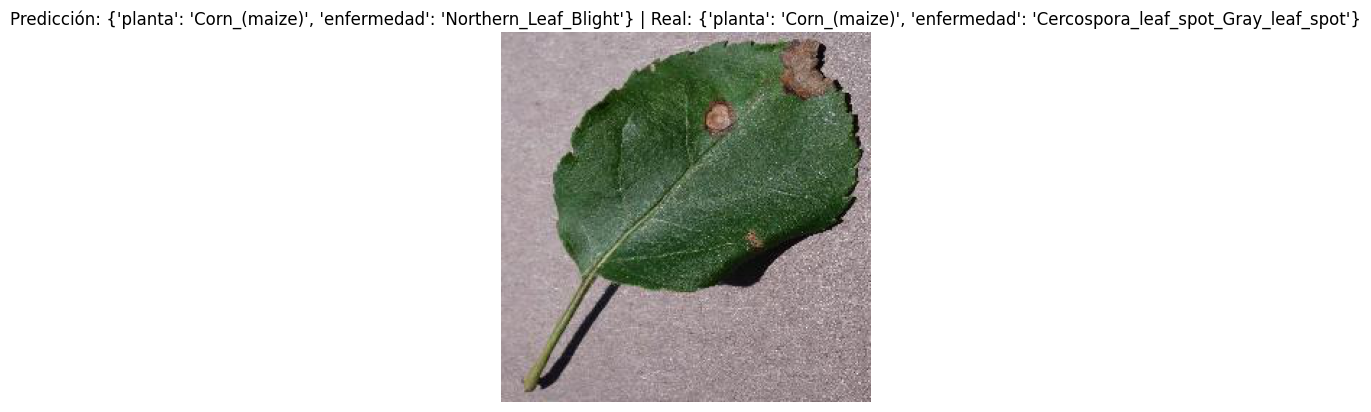

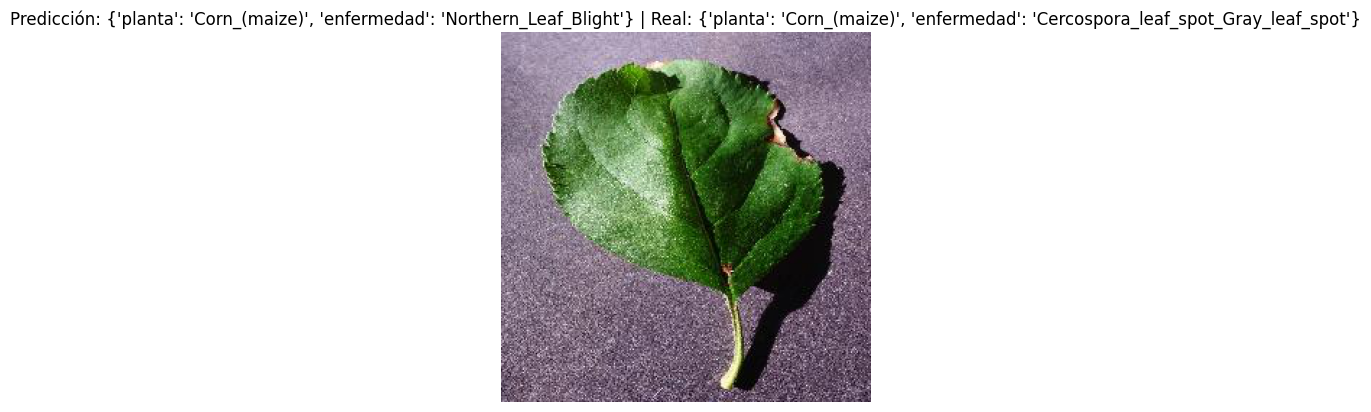

In [2]:
# Función para cargar imágenes mal clasificadas
def load_misclassified_images(experiment_path):
    misclassified_path = os.path.join(experiment_path, "results/misclassified.json")
    if not os.path.exists(misclassified_path):
        print(f"⚠️ No se encontró el archivo de imágenes mal clasificadas en: {misclassified_path}")
        return []

    with open(misclassified_path, "r") as f:
        return json.load(f)

# Visualizar imágenes mal clasificadas
experiment = "color50"  # Cambiar por el experimento deseado
misclassified_images = load_misclassified_images(os.path.join(EXPERIMENTS_PATH, experiment))

# Mostrar las primeras 5 imágenes mal clasificadas
for img_info in misclassified_images[:5]:
    img_path = os.path.join(EXPERIMENTS_PATH, experiment, "images", img_info["filename"])
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Predicción: {img_info['predicted']} | Real: {img_info['actual']}")
    plt.axis("off")
    plt.show()

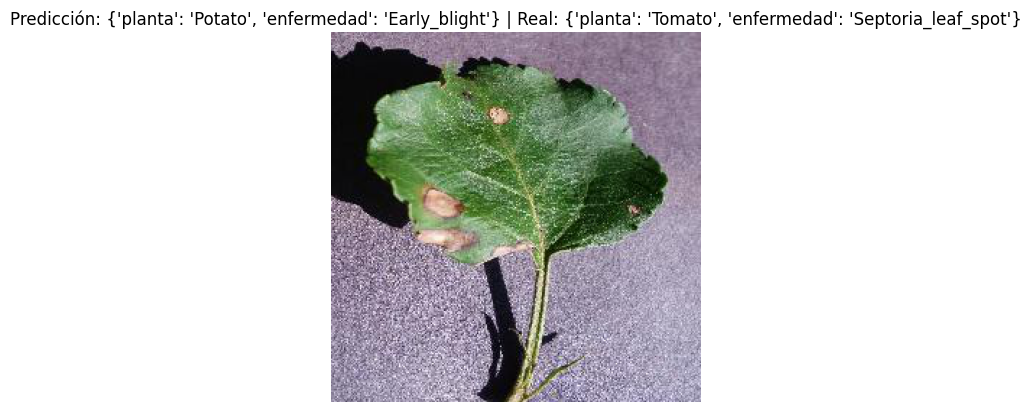

In [3]:
# Visualizar etiquetas reales y predichas de una imagen específica

def visualize_image_labels(image_path, experiment_path):
    # Ensure the function `load_misclassified_images` is defined before calling it
    def load_misclassified_images(experiment_path):
        misclassified_path = os.path.join(experiment_path, "results/misclassified.json")
        if not os.path.exists(misclassified_path):
            print(f"⚠️ No se encontró el archivo de imágenes mal clasificadas en: {misclassified_path}")
            return []

        with open(misclassified_path, "r") as f:
            return json.load(f)

    misclassified_images = load_misclassified_images(experiment_path)

    for img_info in misclassified_images:
        if os.path.basename(image_path) == os.path.basename(img_info["filename"]):
            img = Image.open(image_path)
            plt.imshow(img)
            plt.title(f"Predicción: {img_info['predicted']} | Real: {img_info['actual']}")
            plt.axis("off")
            plt.show()
            return

    print(f"⚠️ La imagen {image_path} no se encuentra en las mal clasificadas.")

# Ejemplo de uso
image_path = os.path.join(ROOT, "imagenes/ee118368-3be8-3bca-bc08-17309040b81b.png")  # Cambiar por la ruta relativa de la imagen
experiment_path = os.path.join(EXPERIMENTS_PATH, "color50")  # Cambiar por el experimento deseado
visualize_image_labels(image_path, experiment_path)

## Visualizar Predicciones Top-K

En esta sección, seleccionaremos una imagen y mostraremos las `top-k` predicciones del modelo.

In [4]:
# Predecir las k clases más probables de una imagen

def predict_image(image_path, experiment_path, top_k=5, known_planta=None):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Cargar configuración y modelo
    config_path = os.path.join(experiment_path, "config_final.yaml")
    modelo_path = os.path.join(experiment_path, "models/best_model.pth")
    data_path = os.path.join(experiment_path, "data")

    config = load_yaml_config(config_path)
    model = build_model(config)
    model.load_state_dict(torch.load(modelo_path, map_location=device))
    model = model.to(device)
    model.eval()

    # Transformaciones de la imagen
    transform = transforms.Compose([
        transforms.Resize(tuple(config["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Índices
    cultivo_to_idx = {c: i for i, c in enumerate(config["plantas"])}
    enfermedad_to_idx = {e: i for i, e in enumerate(config["enfermedades"])}
    idx_to_cultivo = {i: c for c, i in cultivo_to_idx.items()}
    idx_to_enfermedad = {i: e for e, i in enfermedad_to_idx.items()}

    # Cargar imagen
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    # Predecir
    with torch.no_grad():
        out_cultivo, out_enfermedad = model(image)
        probs_c = torch.softmax(out_cultivo, dim=1).squeeze()
        probs_e = torch.softmax(out_enfermedad, dim=1).squeeze()

        if known_planta:
            if known_planta not in cultivo_to_idx:
                raise ValueError(f"La planta '{known_planta}' no está en el config.")
            idx_cultivo = cultivo_to_idx[known_planta]
        else:
            idx_cultivo = probs_c.argmax().item()

        cultivo_pred = idx_to_cultivo[idx_cultivo]

        # Filtrar enfermedades válidas para ese cultivo
        train_csv_path = os.path.join(data_path, "train.csv")
        if not os.path.exists(train_csv_path):
            raise FileNotFoundError(f"No se encuentra el archivo de combinaciones válidas: {train_csv_path}")

        df_train = pd.read_csv(train_csv_path)
        combinaciones_validas = set(zip(df_train["planta"], df_train["nombre_comun"]))

        # Ajustar predicciones para combinaciones inválidas
        if (cultivo_pred, idx_to_enfermedad[probs_e.argmax().item()]) not in combinaciones_validas:
            best_pair = max(
                combinaciones_validas,
                key=lambda pair: probs_c[cultivo_to_idx[pair[0]]] * probs_e[enfermedad_to_idx[pair[1]]]
            )
            cultivo_pred, enfermedad_pred = best_pair
        else:
            enfermedad_pred = idx_to_enfermedad[probs_e.argmax().item()]

        # Obtener las top-k predicciones para cultivo
        topk_cultivo = torch.topk(probs_c, top_k)
        topk_cultivo_indices = topk_cultivo.indices.cpu().numpy()
        topk_cultivo_probs = topk_cultivo.values.cpu().numpy()
        topk_cultivo_result = [(idx_to_cultivo[i], prob) for i, prob in zip(topk_cultivo_indices, topk_cultivo_probs)]

        # Obtener las top-k predicciones para enfermedad
        topk_enfermedad = torch.topk(probs_e, top_k)
        topk_enfermedad_indices = topk_enfermedad.indices.cpu().numpy()
        topk_enfermedad_probs = topk_enfermedad.values.cpu().numpy()
        topk_enfermedad_result = [(idx_to_enfermedad[i], prob) for i, prob in zip(topk_enfermedad_indices, topk_enfermedad_probs)]

    print(f"🌿 Cultivo predicho: {cultivo_pred}")
    print(f"🦠 Nombre común enfermedad predicha: {enfermedad_pred}")
    print("\nTop-k cultivos más probables:")
    for rank, (cultivo, prob) in enumerate(topk_cultivo_result, start=1):
        print(f"{rank}. {cultivo}: {prob:.2f}")

    print("\nTop-k enfermedades más probables:")
    for rank, (enfermedad, prob) in enumerate(topk_enfermedad_result, start=1):
        print(f"{rank}. {enfermedad}: {prob:.2f}")

# Ejemplo de uso
image_path = os.path.join(ROOT, "imagenes/ee118368-3be8-3bca-bc08-17309040b81b.png")  # Cambiar por la ruta relativa de la imagen
experiment_path = os.path.join(ROOT, "experiments/color50")  # Cambiar por la ruta relativa del experimento
predict_image(image_path, experiment_path, top_k=TOP_K)

🌿 Cultivo predicho: Apple
🦠 Nombre común enfermedad predicha: Black_rot

Top-k cultivos más probables:
1. Apple: 0.39
2. Grape: 0.12
3. Tomato: 0.10
4. Peach: 0.07
5. Cherry_(including_sour): 0.07

Top-k enfermedades más probables:
1. Black_rot: 0.29
2. healthy: 0.11
3. Target_Spot: 0.08
4. Apple_scab: 0.07
5. Bacterial_spot: 0.06
